In [47]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# setting the seed for numpy
np.random.seed(10)

# setting the figure parameters for matplotlib
plt.figure(figsize=(8, 6), dpi=300)

<Figure size 2400x1800 with 0 Axes>

<Figure size 2400x1800 with 0 Axes>

In [48]:
# read dataset
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [49]:
# check for null values in the dataset
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [50]:
# check for duplicate samples in the dataset
df.duplicated().unique()

array([False])

/tmp/ipython-input-2268862908.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(math_plot_data, labels=["Male", "Female"])


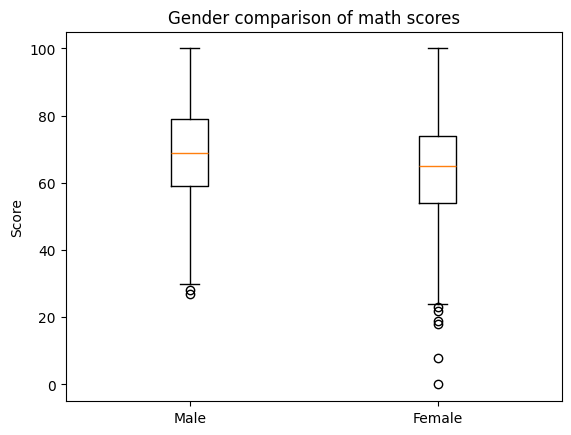

/tmp/ipython-input-2268862908.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(reading_plot_data, labels=["Male", "Female"])


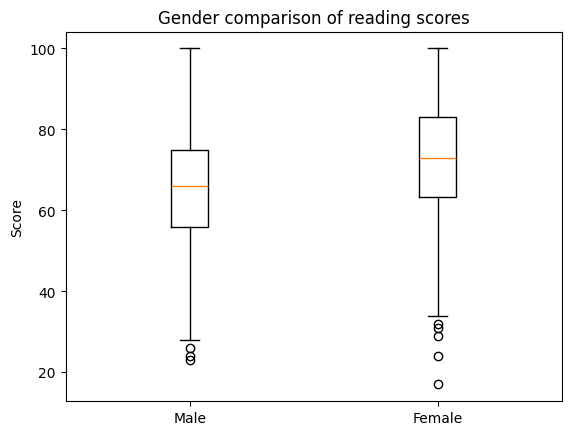

In [51]:
# splitting up the dataset for male and female
data_male = df[df['gender'] == 'male']
data_female = df[df['gender'] == 'female']

math_data_male = data_male['math score'].to_numpy()
math_data_female = data_female['math score'].to_numpy()

reading_data_male = data_male['reading score'].to_numpy()
reading_data_female = data_female['reading score'].to_numpy()

math_plot_data = [math_data_male, math_data_female]
reading_plot_data = [reading_data_male, reading_data_female]

# Create boxplot
plt.boxplot(math_plot_data, labels=["Male", "Female"])
plt.title("Gender comparison of math scores")
plt.ylabel("Score")
plt.show()

plt.boxplot(reading_plot_data, labels=["Male", "Female"])
plt.title("Gender comparison of reading scores")
plt.ylabel("Score")
plt.show()


In [52]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

/tmp/ipython-input-3345097052.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(math_plot_data, labels=["Course completed", "Course not completed"])


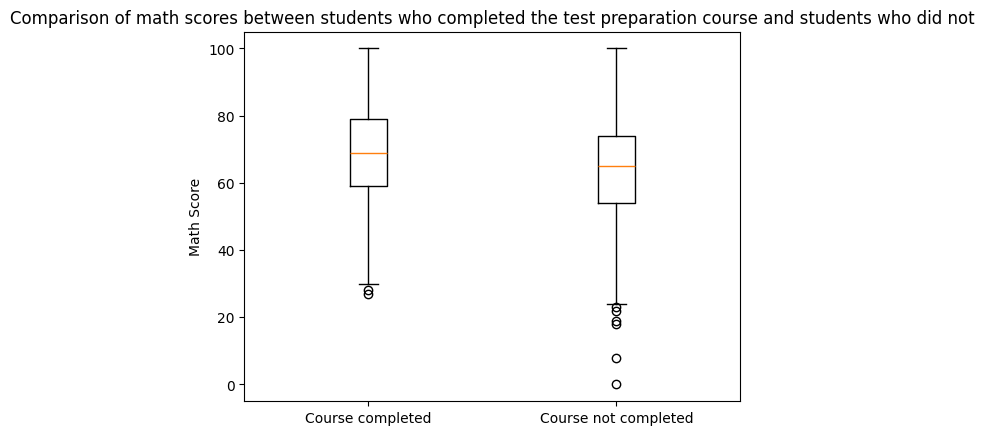

In [53]:
# splitting up the dataset for test preparation course completed and not completed and selecting the math scores
test_preparation_completed_math_scores = df[df['test preparation course'] == 'completed']['math score'].to_numpy()
test_preparation_none_math_scores = df[df['test preparation course'] == 'none']['math score'].to_numpy()

# Create boxplot
plt.boxplot(math_plot_data, labels=["Course completed", "Course not completed"])
plt.title("Comparison of math scores between students who completed the test preparation course and students who did not")
plt.ylabel("Math Score")
plt.show()

In [54]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

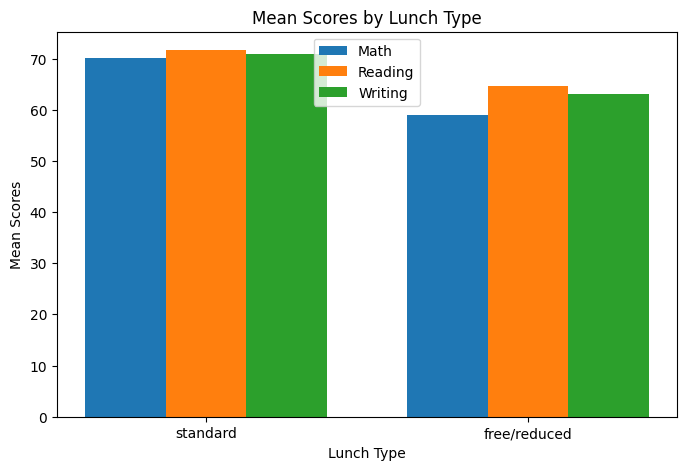

In [55]:
import numpy as np
import matplotlib.pyplot as plt

lunch_categories = df["lunch"].unique()

# filtering the dataset based on the type of lunch
standard_lunch = df[df["lunch"] == "standard"]
free_or_reduced_lunch = df[df["lunch"] == "free/reduced"]

math_means = [standard_lunch['math score'].mean(), free_or_reduced_lunch['math score'].mean()]
reading_means = [standard_lunch['reading score'].mean(), free_or_reduced_lunch['reading score'].mean()]
writing_means = [standard_lunch['writing score'].mean(), free_or_reduced_lunch['writing score'].mean()]

x = np.arange(len(lunch_categories))
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(8, 5))

# Bars for each subject
ax.bar(x - width, math_means, width, label="Math")
ax.bar(x, reading_means, width, label="Reading")
ax.bar(x + width, writing_means, width, label="Writing")

ax.set_xlabel("Lunch Type")
ax.set_ylabel("Mean Scores")
ax.set_title("Mean Scores by Lunch Type")
ax.set_xticks(x)
ax.set_xticklabels(lunch_categories)
ax.legend()

plt.show()


               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


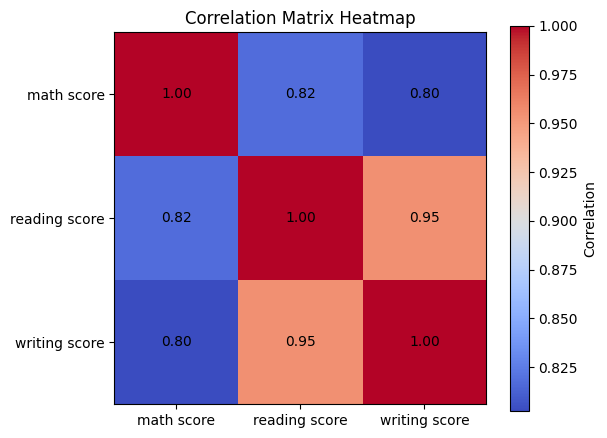

In [56]:
import pandas as pd

# Correlation matrix
corr_matrix = df[["math score", "reading score", "writing score"]].corr()

print(corr_matrix)

plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")

# Tick labels
plt.xticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns)

# Annotate values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Correlation Matrix Heatmap")
plt.show()



In [57]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


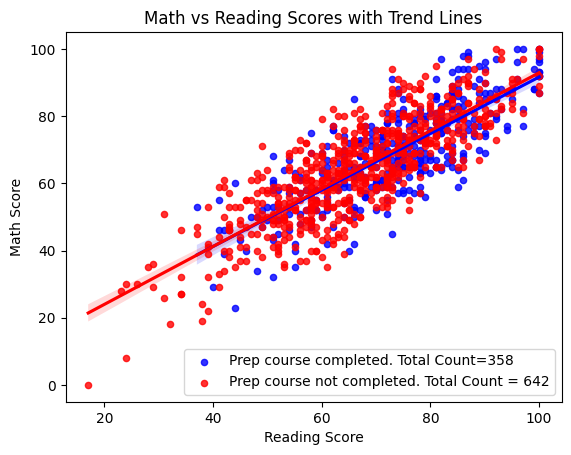

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_completed = df[df['test preparation course'] == 'completed']
df_none = df[df['test preparation course'] == 'none']

math_completed = df[df['test preparation course'] == 'completed']['math score'].to_numpy()
reading_completed = df[df['test preparation course'] == 'completed']['reading score'].to_numpy()

math_none = df[df['test preparation course'] == 'none']['math score'].to_numpy()
reading_none = df[df['test preparation course'] == 'none']['reading score'].to_numpy()

# scatter plot for prep course completed
sns.regplot(x=reading_completed, y=math_completed, label=f"Prep course completed. Total Count={len(df_completed)}",
            scatter_kws={"s": 20, "color":"blue"}, line_kws={"color":"blue"})

# scatter plot for prep course none
sns.regplot(x=reading_none, y=math_none, label=f"Prep course not completed. Total Count = {len(df_none)}",
            scatter_kws={"s": 20, "color":"red"}, line_kws={"color":"red"})
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Math vs Reading Scores with Trend Lines")
plt.legend()
plt.show()
